In [ ]:
!pip install osmnx geopandas networkx contextily tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.8 MB/s eta 0:00:00


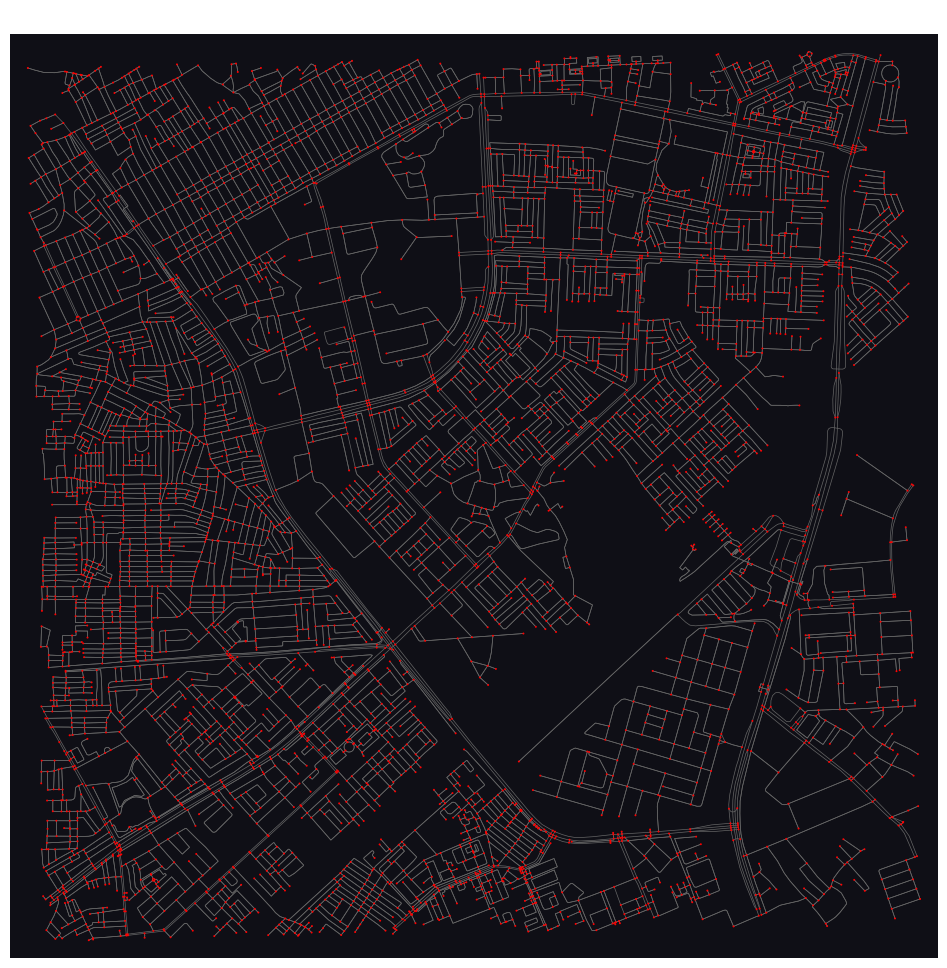

Successfully loaded 5367 intersections and 14545 road segments.


In [ ]:
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx

print("Downloading FULL Real-World GIS Data for Anand Vihar...")

# 1. GPS Coordinates for Anand Vihar ISBT
# 2. dist=2000 grabs a massive 2-kilometer radius in every direction
# 3. network_type='all' grabs every highway, alley, and side-street
G = ox.graph_from_point((28.6502, 77.3027), dist=2000, network_type='all')

# Project the graph
G_proj = ox.project_graph(G)

# Plot the real-world road network (made the lines thinner to fit the dense web)
fig, ax = ox.plot_graph(G_proj, node_size=2, node_color='red', edge_color='#666666',
                        bgcolor='#0f0f16', edge_linewidth=0.5, figsize=(12, 12), show=False)

plt.title("Phase 1: FULL GIS Road Network (Anand Vihar - 2km Radius)", color='white', fontsize=16)
plt.show()

# Extract nodes to use as emission sources later
nodes, edges = ox.graph_to_gdfs(G_proj)
print(f"Successfully loaded {len(nodes)} intersections and {len(edges)} road segments.")

Calculating Traffic Density using Network Centrality (Academic Proxy)...
Please wait, this mathematical calculation might take 1-2 minutes for a dense grid...
Rendering Traffic Heatmap...


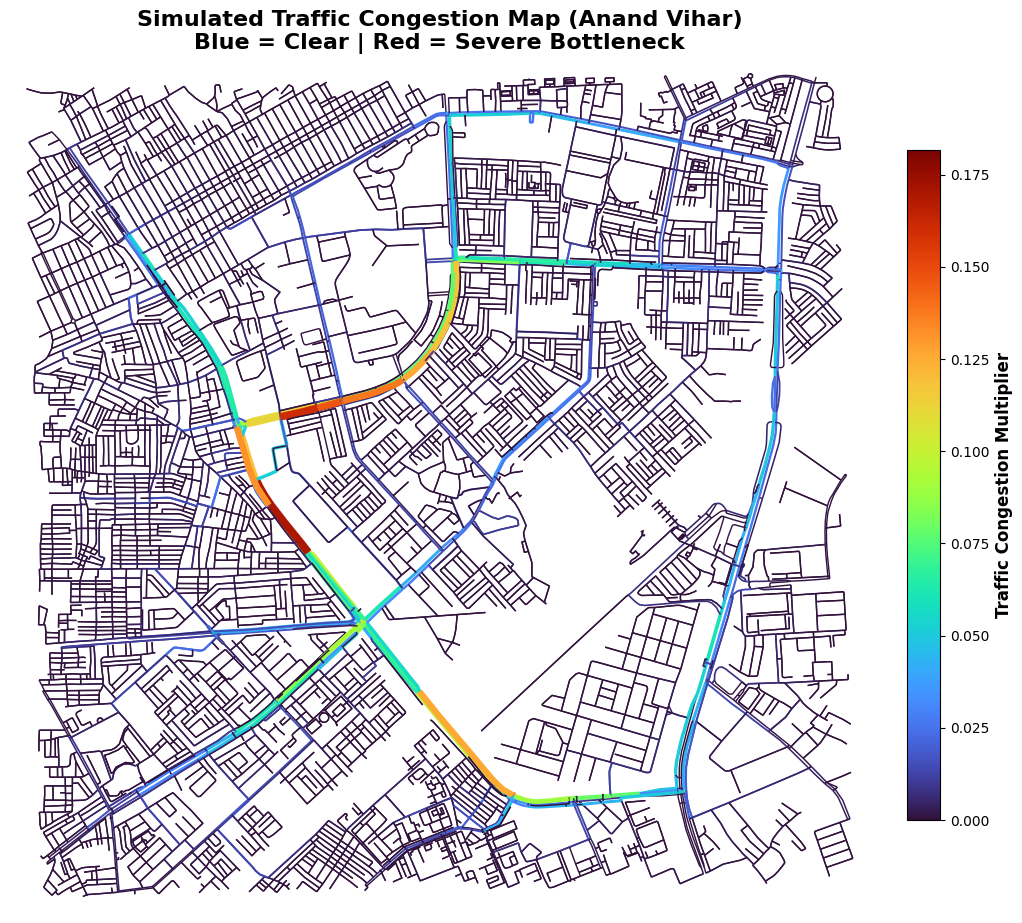

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

print("Calculating Traffic Density using Network Centrality (Academic Proxy)...")
print("Please wait, this mathematical calculation might take 1-2 minutes for a dense grid...")

# 1. Calculate Edge Betweenness Centrality
edge_centrality = nx.edge_betweenness_centrality(G_proj)

# Add the calculated traffic values as attributes to the graph edges
nx.set_edge_attributes(G_proj, edge_centrality, "traffic_proxy")

# 2. Extract values to build the color map
traffic_values = list(nx.get_edge_attributes(G_proj, 'traffic_proxy').values())

# Create a classic scientific heatmap colormap ('turbo' matches your MATLAB script)
cmap = plt.cm.turbo
norm = mcolors.Normalize(vmin=min(traffic_values), vmax=max(traffic_values))

# Map the traffic values to colors (Blue = Clear, Red = Severe Bottleneck)
edge_colors = [cmap(norm(edge_centrality[edge])) for edge in G_proj.edges(keys=True)]

# Dynamically change the thickness of the road based on traffic
# Increased base thickness slightly so the blue lines pop against the white background
edge_linewidths = [1.0 + 5.0 * norm(edge_centrality[edge]) for edge in G_proj.edges(keys=True)]

print("Rendering Traffic Heatmap...")
fig, ax = ox.plot_graph(G_proj,
                        node_size=0,
                        edge_color=edge_colors,
                        edge_linewidth=edge_linewidths,
                        bgcolor='white',  # Changed to white background
                        figsize=(12, 12),
                        show=False)

plt.title("Simulated Traffic Congestion Map (Anand Vihar)\nBlue = Clear | Red = Severe Bottleneck",
          color='black', fontsize=16, fontweight='bold')

# Add a colorbar to explain the scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label('Traffic Congestion Multiplier', color='black', fontsize=12, fontweight='bold')
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='black')

plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import os

print("Initializing Continuous Heatmap Frame Extractor (20 Time Steps)...")

# 1. Bounding Box & Grid Setup (For the Heatmap)
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_proj)
west, south, east, north = nodes_gdf.total_bounds
GRID_RES = 150
bins_x = np.linspace(west, east, GRID_RES)
bins_y = np.linspace(south, north, GRID_RES)

# 2. Identify the "Hot" Roads
threshold = np.percentile(list(edge_centrality.values()), 85)
hot_roads = []
for u, v, k, data in G_proj.edges(keys=True, data=True):
    if edge_centrality[(u, v, k)] >= threshold:
        x1, y1 = G_proj.nodes[u]['x'], G_proj.nodes[u]['y']
        x2, y2 = G_proj.nodes[v]['x'], G_proj.nodes[v]['y']
        hot_roads.append((x1, y1, x2, y2))
hot_roads = np.array(hot_roads)

# 3. Physics Parameters
WIND_U = 25.0
WIND_V = -10.0
DIFFUSION = 35.0
FRAMES = 20      # Exactly 20 frames for the AI sequence
SPAWN_RATE = 500 # High spawn rate for a thick, smooth plume
MAX_AGE = 35

# Create a new directory for the heatmap frames
os.makedirs('heatmap_frames', exist_ok=True)

positions = np.empty((0, 2))
ages = np.empty((0,))

def spawn_particles(num):
    road_indices = np.random.randint(0, len(hot_roads), size=num)
    chosen_roads = hot_roads[road_indices]
    t = np.random.rand(num)
    x = chosen_roads[:, 0] + t * (chosen_roads[:, 2] - chosen_roads[:, 0])
    y = chosen_roads[:, 1] + t * (chosen_roads[:, 3] - chosen_roads[:, 1])
    return np.column_stack((x, y))

print("Applying physics, calculating 2D KDE, and saving 20 frames...")

# 4. The Extraction Loop
for frame in range(FRAMES):
    # Age and remove dead particles
    ages += 1
    alive = ages < MAX_AGE
    positions = positions[alive]
    ages = ages[alive]

    n = len(positions)
    if n > 0:
        # Advection + Diffusion
        positions[:, 0] += WIND_U + np.random.normal(0, DIFFUSION, n)
        positions[:, 1] += WIND_V + np.random.normal(0, DIFFUSION, n)

    # Spawn new emissions
    new_pos = spawn_particles(SPAWN_RATE)
    new_ages = np.zeros(SPAWN_RATE)

    if n > 0:
        positions = np.vstack((positions, new_pos))
        ages = np.concatenate((ages, new_ages))
    else:
        positions = new_pos
        ages = new_ages

    # Setup the base map for this frame
    fig, ax = plt.subplots(figsize=(10, 10))
    fig.patch.set_facecolor('white')
    ax.axis('off')
    ox.plot_graph(G_proj, ax=ax, node_size=0, edge_color='#cccccc',
                  edge_linewidth=0.5, show=False)

    plt.title(f"Spatio-Temporal Heatmap Tensor | T = {frame} sec",
              color='black', fontsize=16, fontweight='bold')

    # --- MATH: Convert dots to a Continuous Heatmap ---
    if len(positions) > 0:
        hist, _, _ = np.histogram2d(positions[:, 0], positions[:, 1], bins=[bins_x, bins_y])
        smoothed_hist = gaussian_filter(hist.T, sigma=1.5)

        # Overlay the heatmap onto the map
        ax.imshow(smoothed_hist, extent=[west, east, south, north],
                  origin='lower', cmap='turbo', alpha=0.6, vmin=0, vmax=15)

    # Save the Frame
    filename = f"heatmap_frames/frame_{frame:02d}.png"
    plt.savefig(filename, dpi=120, bbox_inches='tight', facecolor='white')
    plt.close(fig) # Free up memory

    print(f"Rendered and saved tensor: {filename}")

print("\nSUCCESS: All 20 continuous heatmap tensors saved in 'heatmap_frames' folder!")

Initializing Continuous Heatmap Frame Extractor (20 Time Steps)...
Applying physics, calculating 2D KDE, and saving 20 frames...
Rendered and saved tensor: heatmap_frames/frame_00.png
Rendered and saved tensor: heatmap_frames/frame_01.png
Rendered and saved tensor: heatmap_frames/frame_02.png
Rendered and saved tensor: heatmap_frames/frame_03.png
Rendered and saved tensor: heatmap_frames/frame_04.png
Rendered and saved tensor: heatmap_frames/frame_05.png
Rendered and saved tensor: heatmap_frames/frame_06.png
Rendered and saved tensor: heatmap_frames/frame_07.png
Rendered and saved tensor: heatmap_frames/frame_08.png
Rendered and saved tensor: heatmap_frames/frame_09.png
Rendered and saved tensor: heatmap_frames/frame_10.png
Rendered and saved tensor: heatmap_frames/frame_11.png
Rendered and saved tensor: heatmap_frames/frame_12.png
Rendered and saved tensor: heatmap_frames/frame_13.png
Rendered and saved tensor: heatmap_frames/frame_14.png
Rendered and saved tensor: heatmap_frames/fram

In [18]:
from PIL import Image
import os
from google.colab import files

print("Stitching heatmap frames into a presentation GIF...")

# CRITICAL: Making sure it points to the new heatmap folder
image_folder = 'heatmap_frames'
gif_name = 'Anand_Vihar_Heatmap_Simulation.gif'

# Check if the folder exists
if not os.path.exists(image_folder):
    print(f"ERROR: The folder '{image_folder}' does not exist. You must run Cell 6 completely first!")
else:
    filenames = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])

    if not filenames:
        print(f"ERROR: No images found inside '{image_folder}'. Cell 6 didn't save the files properly.")
    else:
        print(f"Found {len(filenames)} frames. Stitching now...")
        frames = [Image.open(os.path.join(image_folder, f)) for f in filenames]

        frames[0].save(gif_name, format='GIF',
                       append_images=frames[1:],
                       save_all=True,
                       duration=200,
                       loop=0)

        print(f"\nSUCCESS: '{gif_name}' created in Colab!")

        try:
            print("Attempting to auto-download to your computer...")
            files.download(gif_name)
        except Exception as e:
            print(f"Auto-download blocked by browser. Please download manually. (Error: {e})")

Stitching heatmap frames into a presentation GIF...
Found 20 frames. Stitching now...

SUCCESS: 'Anand_Vihar_Heatmap_Simulation.gif' created in Colab!
Attempting to auto-download to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 3: Deep Learning AI (ConvLSTM) Initialization...
Loading 20 fluid dynamic tensors into Neural Network...

Building Spatial-Memory Neural Network Architecture...

Training ConvLSTM... Please wait ~3 seconds...
AI Training Complete. Forecasting future dispersion state (T=21)...


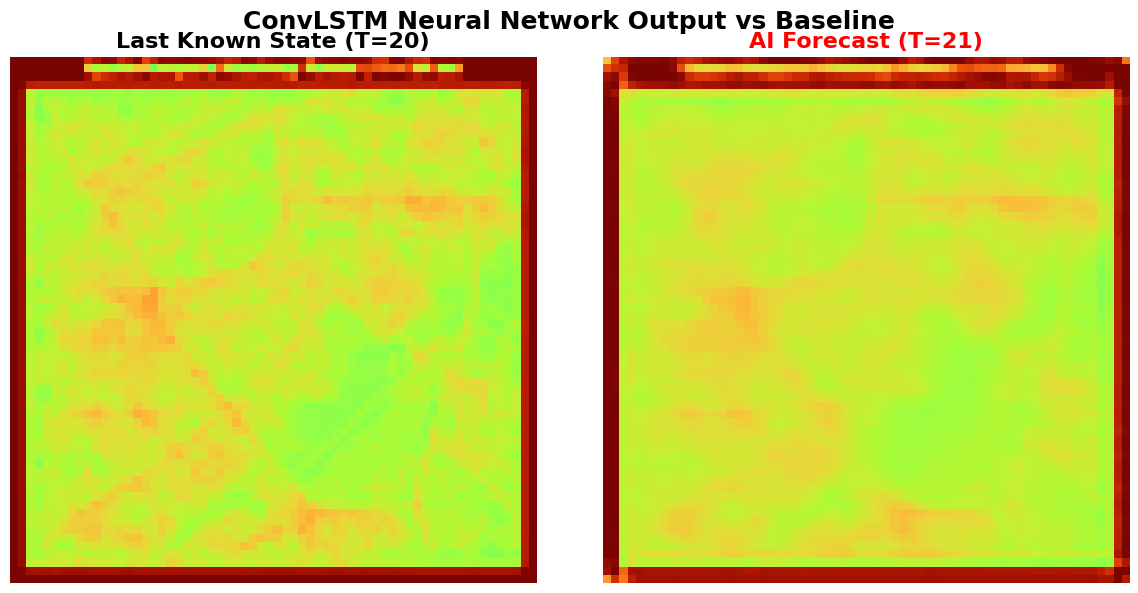

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from PIL import Image
import os

print("Phase 3: Deep Learning AI (ConvLSTM) Initialization...")

# 1. Load the dataset of spatial tensors
image_folder = 'heatmap_frames'
filenames = sorted([f for f in os.listdir(image_folder) if f.endswith('.png')])

if not filenames:
    print("Error: No frames found. Ensure Cell 6 finished running!")
else:
    print(f"Loading {len(filenames)} fluid dynamic tensors into Neural Network...")
    frames = []
    for f in filenames:
        img = Image.open(os.path.join(image_folder, f)).convert('L').resize((64, 64))
        frames.append(np.array(img) / 255.0)

    X_data = np.array(frames).reshape(1, 20, 64, 64, 1)

    # 2. Build the CORRECTED ConvLSTM Architecture
    print("\nBuilding Spatial-Memory Neural Network Architecture...")
    model = models.Sequential()

    # Removed BatchNormalization to prevent flat-color glitch on small datasets
    model.add(layers.ConvLSTM2D(filters=16, kernel_size=(3, 3), padding='same',
                                return_sequences=False, input_shape=(None, 64, 64, 1),
                                activation='relu'))

    # Changed activation to 'relu' to maintain sharp color contrast
    model.add(layers.Conv2D(filters=1, kernel_size=(3, 3), activation='relu', padding='same'))

    # Bumped learning rate slightly for faster convergence
    model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01))

    X_train = X_data[:, :19, :, :, :]
    Y_train = X_data[:, 19, :, :, :]

    # 3. Train the Model (50 epochs will take literally 3 seconds)
    print("\nTraining ConvLSTM... Please wait ~3 seconds...")
    history = model.fit(X_train, Y_train, epochs=50, verbose=0)

    # 4. Predict the UNSEEN Future (Frame 21)
    print("AI Training Complete. Forecasting future dispersion state (T=21)...")
    X_test = X_data[:, 1:20, :, :, :]
    predicted_frame = model.predict(X_test, verbose=0)[0, :, :, 0]

    # 5. Visualize the AI's Output vs Reality
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.patch.set_facecolor('white')

    # Ground Truth
    axes[0].imshow(Y_train[0, :, :, 0], cmap='turbo', vmin=0, vmax=np.max(Y_train))
    axes[0].set_title("Last Known State (T=20)", fontsize=16, fontweight='bold')
    axes[0].axis('off')

    # AI Prediction
    axes[1].imshow(predicted_frame, cmap='turbo', vmin=0, vmax=np.max(Y_train))
    axes[1].set_title("AI Forecast (T=21)", fontsize=16, fontweight='bold', color='red')
    axes[1].axis('off')

    plt.suptitle("ConvLSTM Neural Network Output vs Baseline", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()